# Deep Learning Fundamentals Project

This project has main objective to create a multi-layer perceptron to solve the Modified National Institute of Standards and Technology (MNIST) dataset classification problem. 

Google Collab dependencies: 

In [43]:
# !pip install -q lightning torchmetrics torchvision \
# pandas numpy scikit-learn matplotlib seaborn tensorboard kaggle

Importing necessary libraries: 

In [87]:
import os
import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import socket
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torchvision
import torchmetrics
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
%matplotlib inline

Verifying versions: 

In [45]:
print("Torch:", torch.__version__, "| Python:", platform.python_version(), "| Lightning:", L.__version__)


Torch: 2.8.0 | Python: 3.13.2 | Lightning: 2.5.5


Verifying GPU access: 

In [46]:
def pick_device():
    if torch.cuda.is_available(): return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available(): return "mps"
    return "cpu"


DEVICE = pick_device()
print("Using device:", DEVICE)

Using device: mps


# Downloading dataset from Kaggle: 

After kaggle.json file has been downloaded, on google collab: 
1) Congigure credentials
2) Move token
3) Set permissions
4) Make a directory for competition data
5) Download competition data into the new data directory 

In [47]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/&& chmod 600 ~/.kaggle/kaggle.json
# !mkdir -p data
# !kaggle competitions download -c digit-recognizer -p data
# !unzip -o data/digit-recognizer.zip -d data
# !ls -lah data

Locally via command line (same steps as above): 

In [48]:
# mkdir -p ~/.kaggle
# mv ~/Downloads/kaggle.json ~/.kaggle/
# chmod 600 ~/.kaggle/kaggle.json
# mkdir -p data
# kaggle competitions download -c digit-recognizer -p data
# unzip -o data/digit-recognizer.zip -d data
# ls -lh data

# Initial data exploration

Looking at the shape of the data: 

In [ ]:
%cd /Users/bt/Documents/turing/deep_learning
print("cwd:", os.getcwd())

/Users/bt/Documents/turing/deep_learning
cwd: /Users/bt/Documents/turing/deep_learning


In [50]:
df = pd.read_csv("data/train.csv")
print("Data shape:", df.shape)

Data shape: (42000, 785)


In [51]:
df_test = pd.read_csv("data/test.csv")
print("Test data shape:", df_test.shape)

Test data shape: (28000, 784)


There are 42000 images in the training dataset, with 785 columns (flattened image, 28*28 grayscale image with label for each row.) The test data does not have labels.

Looking at data types: 

In [52]:
df.dtypes.groupby(df.dtypes).count()

int64    785
dtype: int64

Replace empty strings/whitespace to null values: 

In [53]:
df.select_dtypes('object').replace(r'^\s*$', np.nan, regex=True, inplace=True)

Any infinite values in the dataset? 

In [54]:
np.isinf(df.to_numpy()).any()

np.False_

No infinite values in the dataset.

Are there any null values in this dataset? 

In [55]:
print('nulls:', df.isna().sum().sum())

nulls: 0


No null values in this dataset. Are there any duplicated images? 

In [56]:
print('duplicates:', df.duplicated().sum())

duplicates: 0


No duplicate values are present in this dataset (including labels). What if the label is excluded? 

In [57]:
pix = df.drop(columns='label', errors='ignore')
print('duplicates:', pix.duplicated().sum())

duplicates: 0


No duplicate values are present in this dataset. 

Now, looking at numeric ranges: 
- Labels should be integers from 0-9, 
- Pixel range should be from 0-255.

In [58]:
invalid_mask = (pix < 0) | (pix > 255)
invalid_rows = invalid_mask.any(axis=1)
invalid_indices = df.index[invalid_rows]
print("Number of invalid rows:", invalid_rows.sum())
print("Indices of invalid rows:", list(invalid_indices))


Number of invalid rows: 0
Indices of invalid rows: []


In [59]:
print("Min pixel value:", pix.min().min())
print("Max pixel value:", pix.max().max())

Min pixel value: 0
Max pixel value: 255


In [60]:
print("Min label value:", df['label'].min())
print("Max label value:", df['label'].max())

Min label value: 0
Max label value: 9


All ranges are as expected. Are there any images that are all black? 

In [61]:
(pix.sum(axis=1) == 0).sum()

np.int64(0)

No images are all black. How about any images that are all white? 

In [62]:
pix.eq(255).all(axis=1).sum()

np.int64(0)

No images are all white. How about any outlier image rows? 

If an image is valid, the sum of all pixel values should be around the average value for all images in the dataset. Computing the total pixel intensity per image: 

In [63]:
row_sum = pix.sum(axis=1)

Now, computing z scores of those sums: 

In [64]:
z = zscore(row_sum)

It is possible to look at the distribution of total brightness per image: 

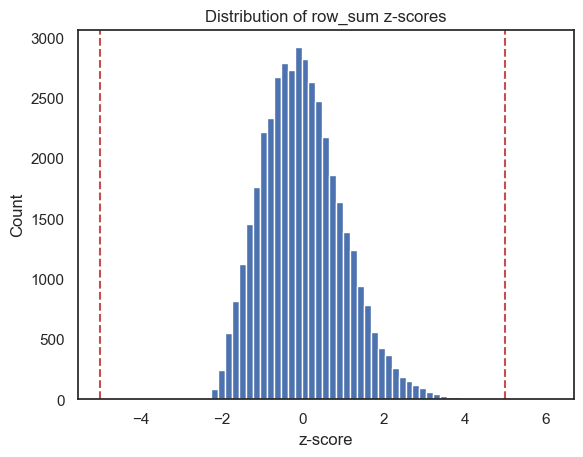

In [65]:
plt.hist(z, bins=50)
plt.axvline(5, color='r', linestyle='--')
plt.axvline(-5, color='r', linestyle='--')
plt.title("Distribution of row_sum z-scores")
plt.xlabel("z-score")
plt.ylabel("Count")
plt.show()

Here, each z value represents how many standard deviations an image's total pixel intensity is from the mean.

This looks like a normal distribution for image brightness.

Now, potential outlier rows will have an absolute z value over 5: 

In [66]:
outlier_mask = np.abs(z) > 5
outlier_indices = df.index[outlier_mask]
print("Number of outlier rows:", outlier_mask.sum())
print("Indices:", list(outlier_indices))

Number of outlier rows: 2
Indices: [1285, 8062]


Looking at these: 

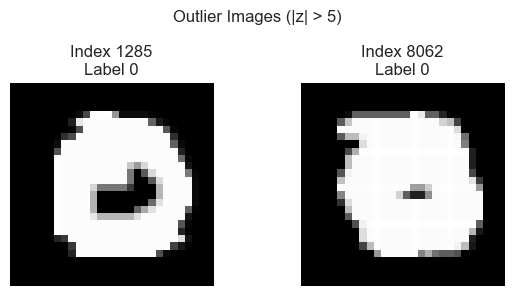

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Loop through the two outliers + subplot axes together
for ax, idx in zip(axes, outlier_indices):
    img = pix.loc[idx].to_numpy().reshape(28, 28)
    ax.imshow(img, cmap='gray')
    if 'label' in df.columns:
        ax.set_title(f"Index {idx}\nLabel {df.loc[idx, 'label']}")
    else:
        ax.set_title(f"Index {idx}")
    ax.axis('off')

plt.suptitle("Outlier Images (|z| > 5)", fontsize=12)
plt.tight_layout()
plt.show()

These still do look like handwritten numbers, and will be kept. 

# Class distribution

Looking at class distribution: 


In [68]:
class_counts = df['label'].value_counts().sort_index()
class_counts

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

Class distribution looks approximately even. Looking at this in terms of class ratios: 

In [69]:
class_ratios = 100*(class_counts / len(df)).round(4)

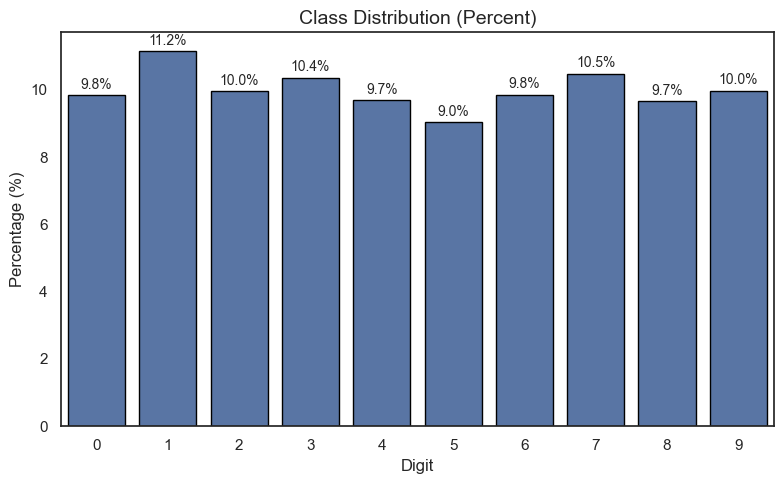

In [70]:
class_df = pd.DataFrame({
    "Digit": class_ratios.index,
    "Percentage": class_ratios.values
})
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=class_df,
    x="Digit", y="Percentage",
    edgecolor="black"
)

plt.title("Class Distribution (Percent)", fontsize=14)
plt.xlabel("Digit", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,   # x-position: center of each bar
        p.get_height() + 0.1,            # y-position: slightly above bar
        f"{p.get_height():.1f}%",        # format label, e.g. 9.85%
        ha="center", va="bottom", fontsize=10
    )
plt.tight_layout()
plt.show()

Classes generally seem to be evenly distributed, with 1 being the most popular class (11% of data). This means that a model's accuracy must be at least 11% in order to be meaningful. 

Before creating a model, it could be useful to examine some random digits to ensure that the data looks as expected: 

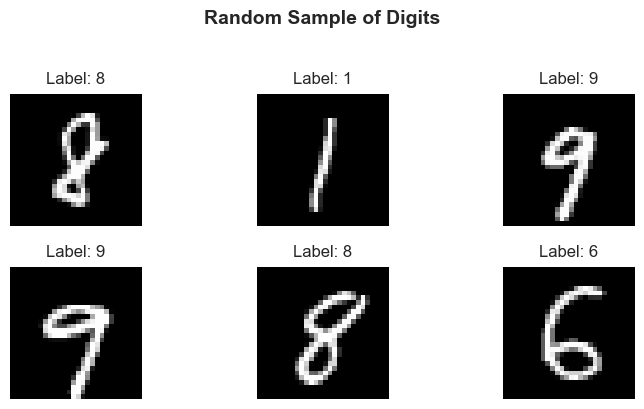

In [71]:
sns.set_theme(style="white")
sample_df = df.sample(6, random_state=42)

plt.figure(figsize=(8, 4))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = row.drop("label").to_numpy().reshape(28, 28)
    label = int(row["label"])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {label}", fontsize=12, pad=8)
    plt.axis("off")

plt.suptitle("Random Sample of Digits", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


Observations: 
- No data cleaning or preparation has been deemed necessary. 
- Dataset is composed of handwritten digit images, flattened with 28*28 pixels per image

# Train, test, validation split

Now, x and y variables can be defined: 

In [72]:
X = df.drop(columns=['label']).values
y = df['label'].values

Next, training, test, and validation data is split from the whole dataset: 

In [73]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


In [74]:
print('Shapes:')
print('train:', X_train.shape, y_train.shape)
print('val:', X_val.shape, y_val.shape)
print('test:', X_test.shape, y_test.shape)

Shapes:
train: (25200, 784) (25200,)
val: (8400, 784) (8400,)
test: (8400, 784) (8400,)


Quick check to ensure that class distribution has been preserved after splitting data: 

In [75]:
class_counts_train = df['label'].value_counts().sort_index()
class_ratios_train = 100*(class_counts_train / len(df)).round(4)

class_counts_val = df['label'].value_counts().sort_index()
class_ratios_val = 100*(class_counts_val / len(df)).round(4)

class_counts_test = df['label'].value_counts().sort_index()
class_ratios_test = 100*(class_counts_test / len(df)).round(4)

class_ratios_df = pd.DataFrame({
    "Digit": class_ratios_train.index,
    "Train (%)": class_ratios_train.values,
    "Validation (%)": class_ratios_val.values,
    "Test (%)": class_ratios_test.values
})
class_ratios_df

,Digit,Train (%),Validation (%),Test (%)
0,0,9.84,9.84,9.84
1,1,11.15,11.15,11.15
2,2,9.95,9.95,9.95
3,3,10.36,10.36,10.36
4,4,9.70,9.70,9.70
5,5,9.04,9.04,9.04
6,6,9.85,9.85,9.85
7,7,10.48,10.48,10.48
8,8,9.67,9.67,9.67
9,9,9.97,9.97,9.97


Class distribution has indeed been preserved across spliting data. 

# Data processing

The data is now normalized to [0, 1], as is common practice for deep learning problems. Some benefits to normalization of raw data include: 
- Raw pixel values (0-255) have a fairly large range and can be unevenly distributed. These large input magnitudes can induce the vanishing gradient problem during backpropagation. 
- Certain activation functions (sigmoid, tanh) work best when the input data is centered and has a small range. 
- Gradient descent can take equal sized steps when all features are on the same range (ex: between 0-1).
- Normalization ensures that all features are treated equally (no bright pixels dominate because of their scale alone). 

In addition, data types are changed to type float32 for x values and as int64 for labels to enable conversion to torch tensors: 

In [76]:
X_train_f = (X_train.astype(np.float32) / 255.0)
X_val_f   = (X_val.astype(np.float32)   / 255.0)
X_test_f  = (X_test.astype(np.float32)  / 255.0)

y_train_i = y_train.astype(np.int64)
y_val_i   = y_val.astype(np.int64)
y_test_i  = y_test.astype(np.int64)

Now, these are converted to torch tensors to use for modeling: 

In [77]:
Xtr = torch.from_numpy(X_train_f)
Xva = torch.from_numpy(X_val_f)
Xte = torch.from_numpy(X_test_f)

ytr = torch.from_numpy(y_train_i)
yva = torch.from_numpy(y_val_i)
yte = torch.from_numpy(y_test_i)

print(Xtr.shape, Xva.shape, Xte.shape, ytr.dtype, Xtr.dtype)

torch.Size([25200, 784]) torch.Size([8400, 784]) torch.Size([8400, 784]) torch.int64 torch.float32


Finally, a training, validation, and test TensorDatasets are defined along with the batch size. Pytorch DataLoaders are also defined to load data by batches, and batch shape and pixel range are verified: 

In [78]:
device = (
torch.device('cuda') if torch.cuda.is_available()
else torch.device('mps') if torch.backends.mps.is_available()
else torch.device('cpu')
)
pin_mem = device.type == 'cuda'


In [ ]:
batch_size = 128

device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu'))
pin_mem = device.type == 'cuda'
num_workers = max(0, (os.cpu_count() or 1) - 1)

train_ds = TensorDataset(Xtr, ytr)
val_ds   = TensorDataset(Xva, yva)
test_ds  = TensorDataset(Xte, yte)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_mem)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_mem)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_mem)

xb, yb = next(iter(train_loader))
print('batch shapes:', xb.shape, yb.shape, xb.dtype, yb.dtype)
print('pixel range:', float(xb.min()), float(xb.max()))


batch shapes: torch.Size([128, 784]) torch.Size([128]) torch.float32 torch.int64
pixel range: 0.0 1.0


Batch size, data type, and pixel ranges are all as expected. 

# Logging setup: 

Tensorboard is used for logging here: 

In [ ]:
%load_ext tensorboard

logger = TensorBoardLogger("experiments", name="baseline")

def _free_port():
    s = socket.socket()
    s.bind(('', 0))
    port = s.getsockname()[1]
    s.close()
    return port
port = _free_port()
print('TensorBoard log dir:', logger.log_dir)
print('Using port:', port)
%tensorboard --logdir {logger.log_dir} --port {port} --host 127.0.0.1


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
TensorBoard log dir: experiments/baseline/version_2
Using port: 54695


# Baseline Softmax Model

The next step is to configure the logger (TensorBoard), callbacks (ckpt for validation accuracy, and early stopping if model performance does not improve over three runs), and trainer. The metric chosen for this dataset evaluation is **accuracy**, as the dataset is balanced.  

Softmax regression is now used as a baseline model. This: 
- builds a single linear layer that maps the 784 features to 10 class logits,
- uses cross entropy loss
- logs loss and accuracy for training and validation data each epoch
- optimizes with Adam 

In [ ]:
ckpt = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}")
early = EarlyStopping(monitor="val_acc", mode="max", patience=3)

trainer = L.Trainer(
    max_epochs=5,
    accelerator="gpu",
    devices=1,
    logger=logger, 
    callbacks=[ckpt, early],
    log_every_n_steps=10,
   deterministic=True,
)

print("Logger dir:", logger.save_dir, "Run name:", logger.name)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Logger dir: experiments Run name: baseline


In [82]:
class SoftmaxBaseline(L.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.layer = nn.Linear(784, 10) 

    def forward(self, x):
        return self.layer(x)

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        self._step(batch, "val")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

Start training: 

In [83]:
model = SoftmaxBaseline(lr=1e-3)
trainer.fit(model, train_loader, val_loader)

print("Best ckpt:", ckpt.best_model_path)
if ckpt.best_model_score is not None:
    print("Best val_acc:", float(ckpt.best_model_score))


  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | layer | Linear | 7.9 K  | train
-----------------------------------------
7.9 K     Trainable params
0         Non-trainable params
7.9 K     Total params
0.031     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/Users/bt/Documents/turing/deep_learning/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


Best ckpt: experiments/baseline/version_2/checkpoints/epoch=4-val_acc=0.9098.ckpt
Best val_acc: 0.909761905670166


Initial validation accuracy: 90.96%

# Multi Layer Perceptron Model: 

Now that a baseline accuracy has been found, a MLP model can be trained to the data: 

In [84]:
class MLP(L.LightningModule):
    def __init__(self, layers=(512, 256), dropout=0.3, lr=1e-3, opt="adam"):
        super().__init__()
        self.save_hyperparameters()

        dims = [784, *layers, 10]
        blocks = []
        for i in range(len(dims) - 2):
            blocks += [
                nn.Linear(dims[i], dims[i+1]),
                nn.ReLU(),
                nn.Dropout(self.hparams.dropout),
            ]
        blocks += [nn.Linear(dims[-2], dims[-1])]
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)  # logits

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        self._step(batch, "val")

    def configure_optimizers(self):
        if self.hparams.opt == "adamw":
            return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-3)
        if self.hparams.opt == "sgd":
            return torch.optim.SGD(self.parameters(), lr=self.hparams.lr, momentum=0.9)
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

This gives: 

In [85]:
logger_mlp = TensorBoardLogger("experiments", name="mlp")

ckpt_mlp = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}")
early_mlp = EarlyStopping(monitor="val_acc", mode="max", patience=3)

trainer_mlp = L.Trainer(
    max_epochs=25,
    accelerator="gpu",
    devices=1,
    logger=logger_mlp,
    callbacks=[ckpt_mlp, early_mlp],
    log_every_n_steps=10,
)

print("Logging to:", logger_mlp.log_dir)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Logging to: experiments/mlp/version_0


In [86]:
model = MLP(layers=(512, 256), dropout=0.3, lr=1e-3, opt="adam")
trainer_mlp.fit(model, train_loader, val_loader)

print("Best ckpt:", ckpt_mlp.best_model_path)
if ckpt_mlp.best_model_score is not None:
    print("Best val_acc:", float(ckpt_mlp.best_model_score))


  | Name | Type       | Params | Mode 
--------------------------------------------
0 | net  | Sequential | 535 K  | train
--------------------------------------------
535 K     Trainable params
0         Non-trainable params
535 K     Total params
2.143     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Best ckpt: experiments/mlp/version_0/checkpoints/epoch=8-val_acc=0.9724.ckpt
Best val_acc: 0.9723809361457825


# Experiments

In [89]:
def make_loaders(batch_size=128):
    train_ds = TensorDataset(Xtr, ytr)
    val_ds   = TensorDataset(Xva, yva)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader

def run_experiment(name, layers=(512,256), dropout=0.3, lr=1e-3, opt="adam", batch_size=128, max_epochs=25):
    print(f"\n=== {name} ===")
    train_loader, val_loader = make_loaders(batch_size)

    logger = TensorBoardLogger("experiments", name=name)
    ckpt   = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}")
    early  = EarlyStopping(monitor="val_acc", mode="max", patience=3)

    L.seed_everything(42, workers=True)
    trainer = L.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        devices=1,
        logger=logger,
        callbacks=[ckpt, early],
        log_every_n_steps=10,
    )

    model = MLP(layers=layers, dropout=dropout, lr=lr, opt=opt)
    trainer.fit(model, train_loader, val_loader)

    best_path = ckpt.best_model_path
    best_val  = float(ckpt.best_model_score) if ckpt.best_model_score is not None else None
    print("Best ckpt:", best_path)
    print("Best val_acc:", best_val)
    return best_path, best_val

In [ ]:
# You already trained a similar (512,256) Adam run; rerun with a named logger for comparison:
run_experiment(name="mlp_bs128_lr1e-3_do0.3_adam_512-256",
               layers=(512,256), dropout=0.3, lr=1e-3, opt="adam", batch_size=128)

# AdamW with weight decay (built into our model’s AdamW)
run_experiment(name="mlp_bs128_lr1e-3_do0.3_adamw_512-256",
               layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw", batch_size=128)

# Slightly higher LR and larger batch
run_experiment(name="mlp_bs256_lr5e-3_do0.2_adam_512-256",
               layers=(512,256), dropout=0.2, lr=5e-3, opt="adam", batch_size=256)

# Narrower network with more dropout
run_experiment(name="mlp_bs128_lr1e-3_do0.5_adam_256-128",
               layers=(256,128), dropout=0.5, lr=1e-3, opt="adam", batch_size=128)

Evaluate candidate checkpoints on the test split

In [ ]:
candidates = [
  "experiments/mlp_bs128_lr1e-3_do0.3_adam_512-256/version_0/checkpoints/epoch=11-val_acc=0.9740.ckpt",
  "experiments/mlp_bs128_lr1e-3_do0.3_adamw_512-256/version_0/checkpoints/epoch=14-val_acc=0.9744.ckpt",
]

for path in candidates:
    model = MLP.load_from_checkpoint(path)
    trainer = L.Trainer(accelerator="gpu", devices=1, logger=False)
    res = trainer.validate(model=model, dataloaders=test_loader)  # uses validation_step on test data
    print("ckpt:", path, "test_acc (as val_acc):", float(res[0]["val_acc"]))

In [ ]:
import numpy as np, torch
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

best_path = "experiments/mlp_bs128_lr1e-3_do0.3_adam_512-256/version_0/checkpoints/epoch=11-val_acc=0.9740.ckpt"
model = MLP.load_from_checkpoint(best_path).to("cuda").eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to("cuda")
        logits = model(xb)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

acc = accuracy_score(y_true, y_pred)
print("Final test accuracy:", acc)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f",
            cbar=True, square=True)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Row-Normalized)")
plt.show()

In [ ]:
model.eval().to("cuda")
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:               # xb shape: (B, 784)
        xb = xb.to("cuda")
        logits = model(xb)
        preds = logits.argmax(1).cpu()
        yb_cpu = yb.cpu()
        wrong_mask = preds != yb_cpu
        if wrong_mask.any():
            wrong_imgs.append(xb[wrong_mask].cpu())   # keep features to reshape later
            wrong_true.append(yb_cpu[wrong_mask])
            wrong_pred.append(preds[wrong_mask])

if len(wrong_imgs):
    wrong_imgs = torch.cat(wrong_imgs)
    wrong_true = torch.cat(wrong_true)
    wrong_pred = torch.cat(wrong_pred)
    print("Total misclassified:", len(wrong_imgs))
else:
    print("No misclassifications captured.")

In [ ]:
import math, matplotlib.pyplot as plt
import numpy as np

n = min(64, len(wrong_imgs))
idx = torch.randperm(len(wrong_imgs))[:n]
cols = 6
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*2, rows*2))
for i, j in enumerate(idx):
    plt.subplot(rows, cols, i+1)
    img = wrong_imgs[j].reshape(28, 28).numpy()  # inputs were flattened in [0,1]
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{int(wrong_true[j])} P:{int(wrong_pred[j])}", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
mask = (wrong_true == 4) & (wrong_pred == 9)
idx_sel = torch.where(mask)[0][:64]
# then plot using idx_sel instead of a random idx

n = min(64, len(wrong_imgs))
#idx = torch.randperm(len(wrong_imgs))[:n]
cols = 6
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*2, rows*2))
for i, j in enumerate(idx_sel):
    plt.subplot(rows, cols, i+1)
    img = wrong_imgs[j].reshape(28, 28).numpy()  # inputs were flattened in [0,1]
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{int(wrong_true[j])} P:{int(wrong_pred[j])}", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd
df_err = pd.DataFrame({"true": wrong_true.numpy(), "pred": wrong_pred.numpy()})
print(df_err.value_counts().head(10))

those mistakes suggest rotation/shape confusions. Let’s do targeted improvements, then (optionally) make a Kaggle submission.

Step 13 — Targeted Improvements

What the errors suggest

9→4, 4→9, 9→5/7: rotation/shear and stroke thickness.
3↔5, 6→5, 7→2, 8→1: shape ambiguity and slight translation.
Fixes: light augmentations, BatchNorm, label smoothing; modest capacity tuning.

Do
Build an augmented train Dataset that reshapes to 1×28×28, applies transforms, then flattens back.
Keep val/test DataLoaders the same (no augmentation).


In [ ]:
from torchvision import transforms

class AugmentedFlatDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        x = self.X[i]                    # shape: (784,)
        y = self.y[i]
        img = x.view(1, 28, 28)         # tensor in [0,1], float32
        if self.transform:
            img = self.transform(img)    # still (1,28,28)
        x_flat = img.view(-1)            # back to (784,)
        return x_flat, y

aug = transforms.Compose([
    transforms.RandomAffine(
        degrees=10, translate=(0.05, 0.05), shear=5, scale=(0.95, 1.05)
    ),
])

train_aug_ds = AugmentedFlatDataset(Xtr, ytr, transform=aug)
train_aug_loader = DataLoader(train_aug_ds, batch_size=128, shuffle=True,
                              num_workers=2, pin_memory=True)

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import lightning as L

class MLP(L.LightningModule):
    def __init__(self, layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw", use_bn=True, ls=0.1):
        super().__init__()
        self.save_hyperparameters()
        dims = [784, *layers, 10]
        blocks = []
        for i in range(len(dims) - 2):
            blocks.append(nn.Linear(dims[i], dims[i+1]))
            if use_bn:
                blocks.append(nn.BatchNorm1d(dims[i+1]))
            blocks.append(nn.ReLU())
            blocks.append(nn.Dropout(dropout))
        blocks.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)  # logits

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y, label_smoothing=self.hparams.ls)
        acc = (logits.argmax(1) == y).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        self._step(batch, "val")

    def configure_optimizers(self):
        if self.hparams.opt == "adamw":
            opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-3)
        elif self.hparams.opt == "sgd":
            opt = torch.optim.SGD(self.parameters(), lr=self.hparams.lr, momentum=0.9)
        else:
            opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)
        return {"optimizer": opt, "lr_scheduler": sch}



In [ ]:
logger = TensorBoardLogger("experiments", name="mlp_aug_bn_ls")
ckpt = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}")
early = EarlyStopping(monitor="val_acc", mode="max", patience=4)

trainer = L.Trainer(max_epochs=25, accelerator="gpu", devices=1,
                    logger=logger, callbacks=[ckpt, early], log_every_n_steps=10)

model = MLP(layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw", use_bn=True, ls=0.1)
trainer.fit(model, train_aug_loader, val_loader)

print("Best:", ckpt.best_model_path, float(ckpt.best_model_score))

Slightly deeper: layers=(768, 384, 192), dropout=0.2–0.3. Activation: LeakyReLU. Weight decay grid: AdamW with wd 1e-4 vs 1e-3.

In [ ]:
import numpy as np, torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LogNorm

# 1) Load best checkpoint and run test inference
best_path = "experiments/mlp_aug_bn_ls/version_0/checkpoints/epoch=16-val_acc=0.9838.ckpt"  # e.g., experiments/mlp_aug_bn_ls/version_0/checkpoints/epoch=XX-val_acc=0.97XX.ckpt
model = MLP.load_from_checkpoint(best_path).to("cuda").eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to("cuda")
        logits = model(xb)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds); y_true = np.concatenate(all_labels)
test_acc = accuracy_score(y_true, y_pred)
print("Final test accuracy:", test_acc)
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))

# 2) Confusion matrices
labels = list(range(10))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 2a) Raw counts
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Counts)")
plt.tight_layout(); plt.show()

# 2b) Row-normalized (percent per class)
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Row-Normalized)")
plt.tight_layout(); plt.show()

# 2c) Log scale (highlights small off-diagonals)
cm_log = cm.copy()
cm_log[cm_log == 0] = 1  # avoid log(0)
plt.figure(figsize=(6,5))
sns.heatmap(cm_log, cmap="magma", norm=LogNorm(vmin=1, vmax=cm_log.max()),
            annot=False, cbar=True, square=True, xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Log Scale)")
plt.tight_layout(); plt.show()


In [ ]:
# If not already defined:
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset

class AugmentedFlatDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y, self.transform = X, y, transform
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]            # tensor (784,), float32 [0,1]
        y = self.y[i]
        img = x.view(1, 28, 28)
        if self.transform: img = self.transform(img)
        return img.view(-1), y

aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), shear=5, scale=(0.95, 1.05)),
])

train_aug_ds = AugmentedFlatDataset(Xtr, ytr, transform=aug)
train_aug_loader = DataLoader(train_aug_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

def make_loaders(batch_size=128):
    train_ds = TensorDataset(Xtr, ytr)
    val_ds   = TensorDataset(Xva, yva)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

def run_experiment(name, layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw",
                   batch_size=128, max_epochs=25, use_bn=True, ls=0.0, use_aug=False):
    print(f"\n=== {name} ===")
    base_train_loader, val_loader = make_loaders(batch_size)
    train_loader = train_aug_loader if use_aug else base_train_loader

    logger = TensorBoardLogger("experiments", name=name)
    ckpt   = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}")
    early  = EarlyStopping(monitor="val_acc", mode="max", patience=3)

    L.seed_everything(42, workers=True)
    trainer = L.Trainer(max_epochs=max_epochs, accelerator="gpu", devices=1,
                        logger=logger, callbacks=[ckpt, early], log_every_n_steps=10)

    model = MLP(layers=layers, dropout=dropout, lr=lr, opt=opt, use_bn=use_bn, ls=ls)
    trainer.fit(model, train_loader, val_loader)

    best_path = ckpt.best_model_path
    best_val  = float(ckpt.best_model_score) if ckpt.best_model_score is not None else None
    print("Best ckpt:", best_path)
    print("Best val_acc:", best_val)
    return best_path, best_val

In [ ]:
p1, v1 = run_experiment(name="mlp_aug_noBN_noLS",
                        layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw",
                        batch_size=128, use_bn=False, ls=0.0, use_aug=True)

p2, v2 = run_experiment(name="mlp_aug_BN_noLS",
                        layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw",
                        batch_size=128, use_bn=True, ls=0.0, use_aug=True)

p3, v3 = run_experiment(name="mlp_aug_BN_LS0.1",
                        layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw",
                        batch_size=128, use_bn=True, ls=0.1, use_aug=True)

print("Summary val_acc:", {"noBN_noLS": v1, "BN_noLS": v2, "BN_LS0.1": v3})

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import lightning as L

class MLP(L.LightningModule):
    def __init__(
        self,
        layers=(512, 256),
        dropout=0.3,
        lr=1e-3,
        opt="adamw",
        use_bn=True,
        activation="relu",   # 'relu', 'leaky', 'gelu'
        loss="ce",           # 'ce', 'ce_ls', 'focal'
        ls=0.0,              # label smoothing epsilon (for 'ce_ls')
        gamma=2.0,           # focal loss gamma
        alpha=None           # focal class weights (list of 10 floats or None)
    ):
        super().__init__()
        self.save_hyperparameters()

        act_map = {"relu": nn.ReLU, "leaky": nn.LeakyReLU, "gelu": nn.GELU}
        if activation not in act_map:
            raise ValueError(f"Unknown activation: {activation}")
        Act = act_map[activation]

        dims = [784, *layers, 10]
        blocks = []
        for i in range(len(dims) - 2):
            blocks.append(nn.Linear(dims[i], dims[i+1]))
            if use_bn:
                blocks.append(nn.BatchNorm1d(dims[i+1]))
            blocks.append(Act())
            blocks.append(nn.Dropout(dropout))
        blocks.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)  # logits

    def _compute_loss(self, logits, y):
        if self.hparams.loss == "ce":
            return F.cross_entropy(logits, y)
        if self.hparams.loss == "ce_ls":
            return F.cross_entropy(logits, y, label_smoothing=self.hparams.ls)
        if self.hparams.loss == "focal":
            # Focal loss built on top of CE
            ce = F.cross_entropy(logits, y, reduction="none")
            pt = torch.exp(-ce)
            loss = ((1 - pt) ** self.hparams.gamma) * ce
            if self.hparams.alpha is not None:
                a = torch.as_tensor(self.hparams.alpha, device=logits.device, dtype=loss.dtype)
                loss = a[y] * loss
            return loss.mean()
        raise ValueError(f"Unknown loss: {self.hparams.loss}")

    def _step(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = self._compute_loss(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_acc",  acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, "train")

    def validation_step(self, batch, _):
        self._step(batch, "val")

    def configure_optimizers(self):
        if self.hparams.opt == "adamw":
            opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-3)
        elif self.hparams.opt == "sgd":
            opt = torch.optim.SGD(self.parameters(), lr=self.hparams.lr, momentum=0.9)
        else:
            opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)
        return {"optimizer": opt, "lr_scheduler": sch}


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset

class AugmentedFlatDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y, self.transform = X, y, transform
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]             # tensor (784,), float32 [0,1]
        y = self.y[i]
        img = x.view(1, 28, 28)   # (C,H,W)
        if self.transform: img = self.transform(img)
        return img.view(-1), y

aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), shear=5, scale=(0.95, 1.05)),
])

train_aug_ds = AugmentedFlatDataset(Xtr, ytr, transform=aug)
train_aug_loader = DataLoader(train_aug_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

def make_loaders(batch_size=128):
    train_ds = TensorDataset(Xtr, ytr)
    val_ds   = TensorDataset(Xva, yva)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

In [ ]:
import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

def run_experiment(
    name,
    layers=(512,256),
    dropout=0.3,
    lr=1e-3,
    opt="adamw",
    batch_size=128,
    max_epochs=25,
    use_bn=True,
    activation="relu",   # 'relu', 'leaky', 'gelu'
    loss="ce",           # 'ce', 'ce_ls', 'focal'
    ls=0.0,
    gamma=2.0,
    alpha=None,
    use_aug=True         # True = use augmented loader; False = plain loader
):
    print(f"\n=== {name} ===")
    base_train_loader, val_loader = make_loaders(batch_size)
    train_loader = train_aug_loader if use_aug else base_train_loader

    logger = TensorBoardLogger("experiments", name=name)
    ckpt   = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="{epoch}-{val_acc:.4f}")
    early  = EarlyStopping(monitor="val_acc", mode="max", patience=3)

    L.seed_everything(42, workers=True)
    trainer = L.Trainer(max_epochs=max_epochs, accelerator="gpu", devices=1,
                        logger=logger, callbacks=[ckpt, early], log_every_n_steps=10)

    model = MLP(
        layers=layers, dropout=dropout, lr=lr, opt=opt,
        use_bn=use_bn, activation=activation, loss=loss,
        ls=ls, gamma=gamma, alpha=alpha
    )
    trainer.fit(model, train_loader, val_loader)

    best_path = ckpt.best_model_path
    best_val  = float(ckpt.best_model_score) if ckpt.best_model_score is not None else None
    print("Best ckpt:", best_path)
    print("Best val_acc:", best_val)
    return best_path, best_val


In [ ]:
p_leaky, v_leaky = run_experiment(
    name="mlp_leaky_relu_ce",
    layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw",
    batch_size=128, use_bn=True, activation="leaky",
    loss="ce", ls=0.0, use_aug=True
)

p_focal, v_focal = run_experiment(
    name="mlp_relu_focal",
    layers=(512,256), dropout=0.3, lr=1e-3, opt="adamw",
    batch_size=128, use_bn=True, activation="relu",
    loss="focal", gamma=2.0, alpha=None, use_aug=True
)

print("Summary val_acc:", {"leaky_ce": v_leaky, "relu_focal": v_focal})

In [ ]:
import numpy as np, torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Pick the better checkpoint path by validation accuracy
best_path = p_leaky if (v_leaky or 0) >= (v_focal or 0) else p_focal
print("Chosen best path:", best_path)

# Evaluate
model = MLP.load_from_checkpoint(best_path).to("cuda").eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to("cuda")
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.append(preds); all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds); y_true = np.concatenate(all_labels)
test_acc = accuracy_score(y_true, y_pred)
print("Final test accuracy:", test_acc)
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))

# Confusion matrices
labels = list(range(10))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Counts)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Row-Normalized)")
plt.tight_layout(); plt.show()

cm_log = cm.copy()
cm_log[cm_log == 0] = 1
plt.figure(figsize=(6,5))
sns.heatmap(cm_log, cmap="magma", norm=LogNorm(vmin=1, vmax=cm_log.max()),
            annot=False, cbar=True, square=True, xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Log Scale)")
plt.tight_layout(); plt.show()


In [ ]:
import pandas as pd, numpy as np, torch

best_path = "experiments/mlp_leaky_relu_ce/version_0/checkpoints/epoch=18-val_acc=0.9855.ckpt"

# Load Kaggle test
test_df_k = pd.read_csv("data/test.csv")
Xk = test_df_k.values.astype(np.float32) / 255.0
Xk_t = torch.from_numpy(Xk)

# Load model and predict
model = MLP.load_from_checkpoint(best_path).to("cuda").eval()
preds = []
with torch.no_grad():
    for i in range(0, len(Xk_t), 1024):
        xb = Xk_t[i:i+1024].to("cuda")
        preds.append(model(xb).argmax(1).cpu().numpy())
yk = np.concatenate(preds)

# Save submission
sub = pd.DataFrame({"ImageId": np.arange(1, len(yk)+1), "Label": yk})
sub.to_csv("submission.csv", index=False)
print("Saved submission.csv with", len(sub), "rows")

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
!mkdir -p "/content/drive/MyDrive/mnist_mlp_artifacts"
!cp -r experiments "/content/drive/MyDrive/mnist_mlp_artifacts/"
!cp submission.csv "/content/drive/MyDrive/mnist_mlp_artifacts/" 2>/dev/null || true
print("Copied to Drive:/mnist_mlp_artifacts")

In [ ]:
# Set your best checkpoint path
best_path = "experiments/mlp_leaky_relu_ce/version_0/checkpoints/epoch=18-val_acc=0.9855.ckpt"

# Evaluate on held-out test set and plot confusion matrices
import numpy as np, torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

model = MLP.load_from_checkpoint(best_path).to("cuda").eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to("cuda")
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.append(preds); all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds); y_true = np.concatenate(all_labels)
test_acc = accuracy_score(y_true, y_pred)
print("Final test accuracy:", test_acc)
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))

labels = list(range(10))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Counts)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Row-Normalized)")
plt.tight_layout(); plt.show()

cm_log = cm.copy(); cm_log[cm_log == 0] = 1
plt.figure(figsize=(6,5))
sns.heatmap(cm_log, cmap="magma", norm=LogNorm(vmin=1, vmax=cm_log.max()),
            annot=False, cbar=True, square=True, xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Log Scale)")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np, os
os.makedirs("experiments/summary", exist_ok=True)
np.savez("experiments/summary/split_indices.npz",
         X_train_idx=np.arange(len(Xtr)), X_val_idx=np.arange(len(Xva)), X_test_idx=np.arange(len(Xte)),
         y_train=ytr.numpy(), y_val=yva.numpy(), y_test=yte.numpy())
print("Saved experiments/summary/split_indices.npz")

In [ ]:
import json
best = {
  "checkpoint": best_path,
  "val_acc": 0.9855,            # update if different
  "test_acc": float(test_acc),
  "layers": [512,256],
  "activation": "leaky",
  "dropout": 0.3,
  "bn": True,
  "optimizer": "adamw",
  "lr": 1e-3,
  "batch_size": 128,
  "augmentation": "RandomAffine(±10°, 5% translate, shear=5°, scale±5%)"
}
with open("experiments/summary/best_run.json","w") as f: json.dump(best, f, indent=2)
print("Saved experiments/summary/best_run.json")